In [2]:
import os, glob, re, random
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
import pandas as pd
drive.mount('/content/drive')

# --- image processing ---
import cv2

# ========== Settings ==========
IMG_GLOB = "/content/drive/MyDrive/DATA/*.png" # Updated path to Google Drive
OUT_SIZE = 28
TRAIN_RATIO = 0.7
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

# ========== Helper: label mapping from SnapN.png ==========
def label_from_filename(path: str) -> int:
    """
    10-19   -> 1
    20-29  -> 2
    ...
    90-99 -> 9
    00-09 -> 0
    """
    base = os.path.basename(path)
    # Updated regex to match NN.png format (e.g., 00.png, 15.png)
    m = re.search(r"(\d{2})\.png$", base, re.IGNORECASE)
    if not m:
        # Updated error message to reflect the new expected format
        raise ValueError(f"檔名不符合 NN.png 格式: {base}")
    n = int(m.group(1)) # Extract the two-digit number

    # Implement the new mapping logic
    # The tens digit of n directly gives the label (00-09 -> 0, 10-19 -> 1, etc.)
    label = n // 10
    return label

# ========== Helper: preprocess to MNIST-like (28x28, white digit on black background) ==========
def preprocess_mnist_like(img_bgr: np.ndarray, out_size: int = 28) -> np.ndarray:
		## img_bgr → 輸入圖片 : np.ndarray → 型別是 NumPy array
               ## -> np.ndarray:  這個函式會回傳 numpy array
    """
    Steps:
    1) grayscale
    2) denoise/smooth (Gaussian blur)
    3) Otsu threshold to binary
    4) invert if needed so digit=white (255), background=black (0)
    5) find bounding box of digit, center it on a square canvas
    6) resize to (28,28)
    Output: uint8 image with values in {0,255}
    """
    # 1) gray
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # 2) smooth
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    # 3) Otsu binarize
    _, bin_img = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # 4) invert if needed:
    # want background mostly black, digit white.
    # If white pixels are more than half, likely background is white -> invert.
    white_ratio = (bin_img > 0).mean()
    if white_ratio > 0.5:
        bin_img = 255 - bin_img

    # 5) crop to digit bounding box (based on white pixels)
    coords = cv2.findNonZero(bin_img)  # non-zero are white digit pixels
    if coords is None:
        # totally blank? return black image
        return np.zeros((out_size, out_size), dtype=np.uint8)

    x, y, w, h = cv2.boundingRect(coords)
    digit = bin_img[y:y+h, x:x+w]

    # pad to square
    side = max(w, h)
    canvas = np.zeros((side, side), dtype=np.uint8)
    y_off = (side - h) // 2
    x_off = (side - w) // 2
    canvas[y_off:y_off+h, x_off:x_off+w] = digit

    # 6) resize to 28x28
    resized = cv2.resize(canvas, (out_size, out_size), interpolation=cv2.INTER_AREA)

    return resized.astype(np.uint8)

# ========== Load all images ==========
paths = sorted(glob.glob(IMG_GLOB))
   ##glob.glob(pattern) 會回傳 符合條件的檔案路徑列表 (list)。
   ## 'images/a.jpg', 'images/b.jpg', 'images/c.jpg'
if len(paths) == 0:
    raise FileNotFoundError(f"找不到任何 jpg: {IMG_GLOB}")

X = []
Y = []

for p in paths:
    img = cv2.imread(p)
    if img is None:
        print(f"讀不到圖檔，跳過: {p}")
        continue
    x = preprocess_mnist_like(img, OUT_SIZE)
    y = label_from_filename(p)
    X.append(x)
    Y.append(y)

X = np.stack(X, axis=0)          # (N, 28, 28)
Y = np.array(Y, dtype=np.int64)  # (N,)

print("Total samples:", len(X))
print("X shape:", X.shape, "dtype:", X.dtype, "range:", (X.min(), X.max()))
print("Y shape:", Y.shape, "labels:", sorted(set(Y.tolist())))

# ========== Train/Test split (random 70/30) ==========
idx = np.arange(len(X))
np.random.shuffle(idx)

split = int(len(X) * TRAIN_RATIO)
train_idx = idx[:split]
test_idx  = idx[split:]

x_train, y_train = X[train_idx], Y[train_idx]
x_test,  y_test  = X[test_idx],  Y[test_idx]

print("\nTrain:", x_train.shape, y_train.shape)
print("Test :", x_test.shape, y_test.shape)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total samples: 100
X shape: (100, 28, 28) dtype: uint8 range: (np.uint8(0), np.uint8(255))
Y shape: (100,) labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Train: (70, 28, 28) (70,)
Test : (30, 28, 28) (30,)


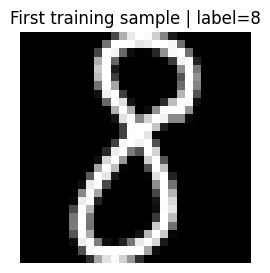

x_train[0,:,:] shape: (28, 28)


In [3]:
# ========== Show first training example ==========
i = 0
plt.figure(figsize=(3,3))
plt.imshow(x_train[i], cmap='gray')
plt.title(f"First training sample | label={y_train[i]}")
plt.axis("off")
plt.show()

# verify indexing like MNIST:
print("x_train[0,:,:] shape:", x_train[0,:,:].shape)


[8 5 7 4 4]


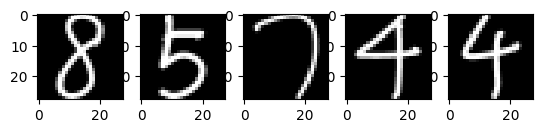

In [4]:
for i in range(0,5):					##  劃出數字
    plt.subplot(1, 5, i+1)
    img = x_train[i]
    plt.imshow(img, cmap="gray")

##cmap: ~matplotlib.colors.Colormap，可選，默認值： 無
##如果沒有，默認為 rc image.cmap 值。 如果 X 具有 RGB(A) 信息，則忽略 cmap


print(y_train[:5])  ## show 出前5筆 y


(70, 784)
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[8 5 7 4 4]
[[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/100
1/1 - 1s - 1s/step - accuracy: 0.1071 - loss: 2.3650 - val_accuracy: 0.0714 - val_loss: 2.3076
Epoch 2/100
1/1 - 0s - 102ms/step - accuracy: 0.3393 - loss: 1.8949 - val_accuracy: 0.2143 - val_loss: 2.2148
Epoch 3/100
1/1 - 0s - 87ms/step - accuracy: 0.7143 - loss: 1.5364 - val_accuracy: 0.2857 - val_loss: 2.1263
Epoch 4/100
1/1 - 0s - 125ms/step - accuracy: 0.9286 - loss: 1.2411 - val_accuracy: 0.3571 - val_loss: 2.0419
Epoch 5/100
1/1 - 0s - 140ms/step - accuracy: 0.9464 - loss: 0.9971 - val_accuracy: 0.3571 - val_loss: 1.9703
Epoch 6/100
1/1 - 0s - 153ms/step - accuracy: 0.9643 - loss: 0.7963 - val_accuracy: 0.3571 - val_loss: 1.9072
Epoch 7/100
1/1 - 0s - 128ms/step - accuracy: 0.9821 - loss: 0.6323 - val_accuracy: 0.3571 - val_loss: 1.8538
Epoch 8/100
1/1 - 0s - 119ms/step - accuracy: 0.9821 - loss: 0.4998 - val_accuracy: 0.3571 - val_loss: 1.8095
Epoch 9/100
1/1 - 0s - 122ms/step - accuracy: 0.9821 - loss: 0.3945 - val_accuracy: 0.3571 - val_loss: 1.7735
Epoch 10/

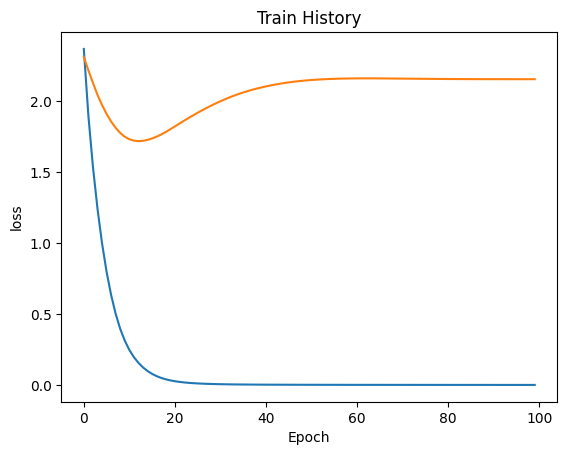

30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.4000 - loss: 1.8943
Accuracy: 0.4000000059604645%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


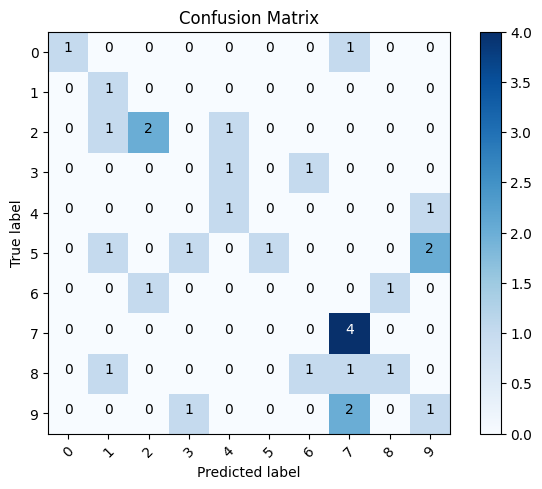

In [5]:
from keras import utils
x_train_reshape = x_train.reshape(x_train.shape[0], 784).astype('float32')
print(x_train_reshape.shape)
x_train_normalized = x_train_reshape / 255
print(x_train_normalized[:5])

print(y_train[:5])
y_train_onehot = utils.to_categorical(y_train)  ## 轉成 10個0/1 碼
print(y_train_onehot[:5])  ## show 出前5筆 y


######################################################
from keras.models import Sequential
from keras.layers import Dense


model = Sequential()
model.add(Dense(units=512, input_dim=784, kernel_initializer="normal", activation="relu"))
model.add(Dense(units=10, kernel_initializer="normal", activation="softmax"))
print(model.summary())
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
## 在分類問題中，最直觀的指標就是 accuracy 在每個 epoch 結束時，會計算「分類正確率」
train_history = model.fit(x=x_train_normalized, y=y_train_onehot, validation_split=0.2, epochs=100, batch_size=200, verbose=2)
## epochs整個訓練資料要被模型完整學習幾次
## batch_size 每次拿多少筆資料來更新一次權重
## 假設你有 10,000 筆資料  batch_size=200  10000 ÷ 200 = 50
## 拿 200 筆 → 算 loss → 更新權重 再拿 200 筆 → 更新 ... 共更新 50 次
## verbose「訓練過程要顯示多少資訊」  verbose=2 每個 epoch 顯示一行

get_ipython().magic('matplotlib inline')
## IPython有一組預先定義好的所謂的魔法函數（Magic Functions），你可以通過命令列的語法形式來訪問它們。

import matplotlib.pyplot as plt
def show_train_history(train_history, train, validation):
    plt.plot(train_history.history[train])
    plt.plot(train_history.history[validation])
    plt.title("Train History")
    plt.ylabel(train)
    plt.xlabel('Epoch')
    plt.show()

show_train_history(train_history, "loss", "val_loss") ## 訓練誤差圖

print(len(y_test))

x_test_reshape = x_test.reshape(x_test.shape[0], 784).astype("float32")
x_test_normalized = x_test_reshape / 255
y_test_onehot = utils.to_categorical(y_test)


scores = model.evaluate(x_test_normalized, y_test_onehot)

print("Accuracy: {}%".format(scores[1]))


import itertools
def plot_confusion_matrix(cm, classes, normalize=False, title="Confusion Matrix", cmap=plt.cm.Blues):
    plt.figure()
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    thresh = cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j], horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show() # Added this line to display the plot

results = np.argmax(model.predict(x_test_reshape), axis=-1)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, results)
plot_confusion_matrix(cm, range(0, 10))  ## 彩色混屯矩陣